# Skin Cancer Detection - Advanced Multimodal Pipeline

Advanced training pipeline for skin cancer detection (3 classes) using PyTorch:
- **Multimodal Architecture**: Fuses image features with metadata (age, sex)
- **Weighted Focal Loss**: Combines class-weighted loss with focal loss for imbalanced data
- **Balanced Stratified Split**: Ensures all 3 classes present in train/val/test sets
- **Mixed Precision Training**: Uses AMP for faster training
- **Early Stopping & Checkpointing**: Saves best model based on validation metrics

In [1]:
## Install dependencies

%pip install timm torchcam pandas seaborn grad-cam imbalanced-learn albumentations opencv-python-headless grad-cam lmdb pyarrow opencv-python albumentations
%pip install --upgrade scikit-learn==1.3.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 74.9 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 37.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.1/295.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 28.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 98.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━

In [2]:
import cv2, os, io, time, warnings
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, classification_report, f1_score, roc_curve, auc
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings('ignore')

# Setup Directories
os.makedirs('/kaggle/working/model_checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/model_results', exist_ok=True)
os.makedirs('/kaggle/working/trained_models', exist_ok=True)


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

## 2.Cấu hình config

In [3]:
# Configuration - Optimized for faster training
IMAGE_SIZE = 224  # Using 224x224 to support all models (vit_base_patch16_224, swin_tiny_patch4_window7_224, etc.)
BATCH_SIZE = 82   # Increased from 64 to reduce iterations
NUM_CLASSES = 3
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
NUM_WORKERS = 4

# Selected best models (reduced from 8 to 4) - CNN + Transformer balance
# MODEL_LIST = ['vgg16', 'resnext50_32x4d', 'vit_base_patch16_224', 'swin_tiny_patch4_window7_224',
#               'efficientnet_b3', 'regnety_080', 'convnext_base', 'halonet26t']
MODEL_LIST = ['vgg16']
TRAIN_CONFIG = {
    'num_epochs': 15,  # Increased from 10 to allow more learning
    'learning_rate': 1e-4,  # Increased from 1e-4 - previous was too slow
    'early_stopping_patience': 7,  # Increased from 5
    'dropout_rate': 0.2,  # Reduced from 0.3 for better feature learning
    'metadata_embedding_dim': 32,
    'use_amp': False,  # Keep disabled for stability
    'gradient_accumulation_steps': 1,
    'use_lr_scheduler': True,  # NEW: Enable learning rate scheduling
    'scheduler_patience': 3,  # Reduce LR if no improvement for 3 epochs
}


In [4]:
# Load Data DataFrame - First 70k images
df = pd.read_csv('/kaggle/input/metadata.csv', low_memory=False).head(70000)

# Handle NaN labels - assign 'unknown'
df['benign_malignant'] = df['benign_malignant'].fillna('unknown')

label_mapping = {'benign': 0, 'malignant': 1, 'unknown': 2}
df['label'] = df['benign_malignant'].map(label_mapping)
df.dropna(subset=['label'], inplace=True)
df['label'] = df['label'].astype(int)

# Print data distribution
print("Data Distribution (First 70k images):")
print(df['benign_malignant'].value_counts())
print(f"\nTotal: {len(df)} samples")
print("\nLabel mapping:")
print(label_mapping)

# Metadata Features
def prepare_metadata_features(df):
    features = []
    if 'age_approx' in df.columns:
        df['age_approx'] = df['age_approx'].fillna(df['age_approx'].median())
        df['age_approx'] = (df['age_approx'] - df['age_approx'].min()) / (df['age_approx'].max() - df['age_approx'].min() + 1e-8)
        features.append('age_approx')
    if 'sex' in df.columns:
        df['sex'] = df['sex'].fillna('unknown')
        dummies = pd.get_dummies(df['sex'], prefix='sex', dtype=float)
        df = pd.concat([df, dummies], axis=1)
        features.extend(dummies.columns.tolist())
    return df, features

df, metadata_features = prepare_metadata_features(df)


Data Distribution (First 70k images):
benign_malignant
benign       53014
malignant     8574
unknown       8122
Name: count, dtype: int64

Total: 69710 samples

Label mapping:
{'benign': 0, 'malignant': 1, 'unknown': 2}


## 4. phân chia dữ liệu


In [5]:
# Chia dữ liệu với stratified sampling - đảm bảo mỗi class có đầy đủ trong train, val, test
from sklearn.model_selection import train_test_split

def balanced_stratified_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Chia dữ liệu theo từng class riêng biệt, đảm bảo:
    - Mỗi class có đều đặn ở train, val, test
    - Giữ tỷ lệ stratified cho mỗi tập
    - Tất cả classes đều có mặt ở mỗi tập dữ liệu
    """
    train_parts = []
    val_parts = []
    test_parts = []
    
    print(f"\n{'='*60}")
    print("STRATIFIED SPLIT PER CLASS")
    print(f"{'='*60}")
    print(f"Target split: Train={train_ratio*100:.1f}%, Val={val_ratio*100:.1f}%, Test={test_ratio*100:.1f}%\n")
    
    # Chia từng class riêng biệt
    for label in sorted(df['label'].unique()):
        class_data = df[df['label'] == label].copy()
        class_name = {0: 'benign', 1: 'malignant', 2: 'unknown'}[label]
        n_samples = len(class_data)
        
        print(f"Class {label} ({class_name}): {n_samples} samples")
        
        # Bước 1: Chia train và temp (train_ratio : 1-train_ratio)
        train_class, temp_class = train_test_split(
            class_data,
            train_size=train_ratio,
            random_state=random_state,
            shuffle=True
        )
        
        # Bước 2: Chia temp thành val và test (val_ratio/(1-train_ratio) : test_ratio/(1-train_ratio))
        val_ratio_adjusted = val_ratio / (1 - train_ratio)
        val_class, test_class = train_test_split(
            temp_class,
            train_size=val_ratio_adjusted,
            random_state=random_state,
            shuffle=True
        )
        
        train_parts.append(train_class)
        val_parts.append(val_class)
        test_parts.append(test_class)
        
        print(f"  → Train: {len(train_class)} ({len(train_class)/n_samples*100:.1f}%)")
        print(f"  → Val:   {len(val_class)} ({len(val_class)/n_samples*100:.1f}%)")
        print(f"  → Test:  {len(test_class)} ({len(test_class)/n_samples*100:.1f}%)")
        print()
    
    # Ghép lại và shuffle
    train_df = pd.concat(train_parts, ignore_index=True).sample(frac=1, random_state=random_state).reset_index(drop=True)
    val_df = pd.concat(val_parts, ignore_index=True).sample(frac=1, random_state=random_state).reset_index(drop=True)
    test_df = pd.concat(test_parts, ignore_index=True).sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return train_df, val_df, test_df

# Áp dụng split
train_df, val_df, test_df = balanced_stratified_split(
    df, 
    train_ratio=0.7, 
    val_ratio=0.15, 
    test_ratio=0.15,
    random_state=SEED
)

# Kiểm tra kết quả
print(f"{'='*60}")
print("PHÂN CHIA DỮ LIỆU HOÀN CHỈNH")
print(f"{'='*60}")
print(f"\nTổng số mẫu:")
print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

# Hiển thị phân bố nhãn
print(f"\n{'='*60}")
print("PHÂN BỐ NHÃN CHI TIẾT")
print(f"{'='*60}")

label_names = {0: 'Benign', 1: 'Malignant', 2: 'Unknown'}

datasets = [('TRAIN', train_df), ('VALIDATION', val_df), ('TEST', test_df)]
for set_name, dataset in datasets:
    print(f"\n{set_name}:")
    for label in sorted(dataset['label'].unique()):
        count = len(dataset[dataset['label'] == label])
        pct_of_set = count / len(dataset) * 100
        pct_of_class = count / len(df[df['label'] == label]) * 100
        print(f"  {label_names[label]}: {count:6d} ({pct_of_set:5.1f}% of set, {pct_of_class:5.1f}% of class)")

# Kiểm tra tất cả classes có mặt ở tất cả tập
print(f"\n{'='*60}")
print("KIỂM TRA ĐẦY ĐỦ NHÃN")
print(f"{'='*60}")
for set_name, dataset in datasets:
    unique_labels = sorted(dataset['label'].unique())
    all_labels_present = len(unique_labels) == 3 and all(label in unique_labels for label in [0, 1, 2])
    status = "✅ PASS" if all_labels_present else "❌ FAIL"
    print(f"{set_name}: {status} - Classes present: {[label_names[l] for l in unique_labels]}")



STRATIFIED SPLIT PER CLASS
Target split: Train=70.0%, Val=15.0%, Test=15.0%

Class 0 (benign): 53014 samples
  → Train: 37109 (70.0%)
  → Val:   7952 (15.0%)
  → Test:  7953 (15.0%)

Class 1 (malignant): 8574 samples
  → Train: 6001 (70.0%)
  → Val:   1286 (15.0%)
  → Test:  1287 (15.0%)

Class 2 (unknown): 8122 samples
  → Train: 5685 (70.0%)
  → Val:   1218 (15.0%)
  → Test:  1219 (15.0%)

PHÂN CHIA DỮ LIỆU HOÀN CHỈNH

Tổng số mẫu:
Train: 48795 (70.0%)
Validation: 10456 (15.0%)
Test: 10459 (15.0%)
Total: 69710

PHÂN BỐ NHÃN CHI TIẾT

TRAIN:
  Benign:  37109 ( 76.1% of set,  70.0% of class)
  Malignant:   6001 ( 12.3% of set,  70.0% of class)
  Unknown:   5685 ( 11.7% of set,  70.0% of class)

VALIDATION:
  Benign:   7952 ( 76.1% of set,  15.0% of class)
  Malignant:   1286 ( 12.3% of set,  15.0% of class)
  Unknown:   1218 ( 11.6% of set,  15.0% of class)

TEST:
  Benign:   7953 ( 76.0% of set,  15.0% of class)
  Malignant:   1287 ( 12.3% of set,  15.0% of class)
  Unknown:   1219 (

## 5. Chuẩn bị dữ liệu Dataset

In [6]:
class SkinCancerDataset(Dataset):
    def __init__(self, df, image_folder, metadata_features, is_train=True):
        self.df = df.reset_index(drop=True)
        self.image_folder = image_folder
        self.metadata_features = metadata_features
        self.is_train = is_train
        
        # Optimized augmentation (less intensive)
        if self.is_train:
            self.transform = A.Compose([
                A.Resize(IMAGE_SIZE, IMAGE_SIZE),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),  # Reduced from 0.5
                A.Rotate(limit=10, p=0.3),  # Reduced from 15, 0.5
                A.RandomBrightnessContrast(p=0.15),  # Reduced from 0.2
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(IMAGE_SIZE, IMAGE_SIZE),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load image
        image_id = row['isic_id']
        image_path = os.path.join(self.image_folder, f"{image_id}.jpg")
        
        # Read with OpenCV (faster than PIL)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Apply transform
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        # Metadata
        metadata = torch.tensor(row[self.metadata_features].values.astype(np.float32))
        
        # Label
        label = torch.tensor(row['label'], dtype=torch.long)
        
        return image, metadata, label


In [7]:
# Tạo datasets và dataloaders
train_dataset = SkinCancerDataset(
    train_df, 
    '/kaggle/input/images', 
    metadata_features, 
    is_train=True
)
val_dataset = SkinCancerDataset(
    val_df, 
    '/kaggle/input/images', 
    metadata_features, 
    is_train=False
)
test_dataset = SkinCancerDataset(
    test_df, 
    '/kaggle/input/images', 
    metadata_features, 
    is_train=False
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Dataset sizes - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Dataset sizes - Train: 48795, Val: 10456, Test: 10459


## 6. cấu hình train


### Định nghĩa hàm loss & cấu hình train

In [8]:
class SimpleMultimodalModel(nn.Module):
    def __init__(self, model_name, num_classes, metadata_dim, embedding_dim=64, dropout=0.3):
        super().__init__()
        
        # Image encoder
        self.image_encoder = timm.create_model(
            model_name, 
            pretrained=True, 
            num_classes=0
        )
        
        # Get feature dimension and handle variable input sizes
        with torch.no_grad():
            dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE)
            features = self.image_encoder(dummy)
            
            # Handle different output shapes from CNNs and Transformers
            if len(features.shape) == 4:  # CNN output: (batch, channels, height, width)
                self.img_feat_dim = features.shape[1]
                # Add adaptive average pooling to handle different input sizes
                self.pool = nn.AdaptiveAvgPool2d((1, 1))
            elif len(features.shape) == 3:  # Transformer output: (batch, seq_len, embed_dim)
                self.img_feat_dim = features.shape[-1]
                self.pool = None
            else:  # Already flattened
                self.img_feat_dim = features.shape[1]
                self.pool = None
        
        # Metadata encoder - with layer norm instead of batch norm for stability
        if metadata_dim > 0:
            self.metadata_encoder = nn.Sequential(
                nn.Linear(metadata_dim, embedding_dim),
                nn.LayerNorm(embedding_dim),  # Changed from BatchNorm1d for stability
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            classifier_input = self.img_feat_dim + embedding_dim
        else:
            self.metadata_encoder = None
            classifier_input = self.img_feat_dim
        
        # Classifier - simplified to reduce NaN risk
        self.classifier = nn.Sequential(
            nn.Linear(classifier_input, classifier_input // 2),
            nn.LayerNorm(classifier_input // 2),  # Changed from BatchNorm1d
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_input // 2, num_classes)
        )
        
        # Initialize weights with small values to prevent explosion
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights with Xavier uniform for stability"""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight, gain=0.5)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
        
    def forward(self, image, metadata=None):
        # Image features
        img_features = self.image_encoder(image)
        
        # Handle different output shapes
        if len(img_features.shape) == 4:  # CNN output
            img_features = self.pool(img_features).squeeze(-1).squeeze(-1)
        elif len(img_features.shape) == 3:  # Transformer output
            # Take CLS token or average pooling
            if img_features.shape[1] > 1:
                img_features = img_features[:, 0]  # CLS token
            else:
                img_features = img_features.squeeze(1)
        
        # Normalize image features
        img_features = F.normalize(img_features, p=2, dim=1)
        
        # Metadata features
        if self.metadata_encoder is not None and metadata is not None:
            meta_features = self.metadata_encoder(metadata)
            # Normalize metadata features
            meta_features = F.normalize(meta_features, p=2, dim=1)
            features = torch.cat([img_features, meta_features], dim=1)
        else:
            features = img_features
        
        return self.classifier(features)


In [9]:
class WeightedFocalLoss(nn.Module):
    """Kết hợp Class-weighted Loss với Focal Loss - với numerical stability tối đa"""
    def __init__(self, class_weights=None, alpha=1.0, gamma=0.0, reduction='mean'):
        super(WeightedFocalLoss, self).__init__()
        self.class_weights = class_weights
        self.alpha = alpha
        self.gamma = gamma  # Set to 0.0 to disable focal (just weighted CE for stability)
        self.reduction = reduction
        self.eps = 1e-7
    
    def forward(self, inputs, targets):
        """
        Numerically stable loss computation
        When gamma=0, this becomes simple weighted cross-entropy
        """
        # Validate inputs for NaN/Inf
        if torch.isnan(inputs).any() or torch.isinf(inputs).any():
            print("⚠️ WARNING: NaN/Inf detected in model outputs!")
            return torch.tensor(0.0, device=inputs.device, requires_grad=True)
        
        # Get CE loss with class weights (numerically more stable)
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.class_weights)
        
        # If gamma is 0, just return weighted CE loss (most stable)
        if self.gamma == 0.0:
            if self.reduction == 'mean':
                return ce_loss.mean()
            elif self.reduction == 'sum':
                return ce_loss.sum()
            return ce_loss
        
        # Get probabilities safely
        p = F.softmax(inputs, dim=1)
        p_t = p.gather(1, targets.unsqueeze(1)).squeeze(1)
        
        # Clamp probabilities to avoid log(0) and numerical issues
        p_t = torch.clamp(p_t, min=self.eps, max=1.0 - self.eps)
        
        # Compute focal weight in log space: (1 - p_t)^gamma = exp(gamma * log(1 - p_t))
        log_focal_weight = self.gamma * torch.log(1.0 - p_t)
        focal_weight = torch.exp(log_focal_weight)
        
        # Clamp focal weight to avoid explosion
        focal_weight = torch.clamp(focal_weight, min=0, max=10.0)
        
        # Apply focal weighting
        focal_loss = self.alpha * focal_weight * ce_loss
        
        # Final safety check
        if torch.isnan(focal_loss).any() or torch.isinf(focal_loss).any():
            print("⚠️ WARNING: NaN/Inf in focal loss, returning CE loss instead")
            if self.reduction == 'mean':
                return ce_loss.mean()
            else:
                return ce_loss.sum()
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


In [10]:
class ModelTrainer:
    def __init__(self, model, model_name, device, class_weights=None):
        self.model = model
        self.model_name = model_name
        self.device = device
        self.use_amp = TRAIN_CONFIG['use_amp']
        self.gradient_accumulation_steps = TRAIN_CONFIG['gradient_accumulation_steps']
        
        if self.use_amp:
            self.scaler = GradScaler()
        
        # History
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_f1': [], 'val_f1': [],
            'lr': []
        }
        
        # Tính class weights nếu không được cung cấp
        if class_weights is None:
            labels = train_df['label'].values
            class_counts = np.bincount(labels)
            total = len(labels)
            class_weights = total / (len(class_counts) * (class_counts + 1e-8))
            class_weights = class_weights / class_weights.sum() * len(class_counts)
            
            if np.isnan(class_weights).any() or np.isinf(class_weights).any():
                class_weights = np.ones(len(class_counts))
            
            class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
        else:
            class_weights = class_weights.to(device)
        
        # Loss function: Weighted Focal Loss
        self.criterion = WeightedFocalLoss(class_weights=class_weights, alpha=1.0, gamma=1.0)
        
        # Optimizer
        self.optimizer = optim.AdamW(
            model.parameters(), 
            lr=TRAIN_CONFIG['learning_rate'],
            weight_decay=1e-4
        )
        
        # Checkpoint management
        self.checkpoint_dir = f'/kaggle/working/model_checkpoints/{model_name}'
        self.results_dir = f'/kaggle/working/model_results/{model_name}'
        os.makedirs(self.checkpoint_dir, exist_ok=True)
        os.makedirs(self.results_dir, exist_ok=True)
        
        self.best_val_acc = 0.0
        self.early_stop_counter = 0
    
    def train_epoch(self, train_loader):
        self.model.train()
        total_loss = 0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        nan_count = 0
        
        self.optimizer.zero_grad()
        
        pbar = tqdm(train_loader, desc=f"Training {self.model_name}")
        for batch_idx, (images, metadata, labels) in enumerate(pbar):
            images = images.to(self.device)
            metadata = metadata.to(self.device)
            labels = labels.to(self.device)
            
            # Check for NaN in inputs
            if torch.isnan(images).any() or torch.isnan(metadata).any():
                print(f"⚠️ NaN detected in batch {batch_idx} inputs")
                continue
            
            # Forward pass (no AMP for stability)
            outputs = self.model(images, metadata)
            
            # Check for NaN in outputs
            if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                print(f"⚠️ NaN/Inf detected in model output at batch {batch_idx}")
                nan_count += 1
                if nan_count > 3:
                    print("❌ Too many NaN batches, stopping training")
                    return None, None, None
                self.optimizer.zero_grad()
                continue
            
            # Compute loss
            loss = self.criterion(outputs, labels)
            
            # Check for NaN in loss
            if torch.isnan(loss).any() or torch.isinf(loss).any():
                print(f"⚠️ NaN/Inf detected in loss at batch {batch_idx}, loss={loss.item()}")
                nan_count += 1
                if nan_count > 3:
                    print("❌ Too many NaN losses, stopping training")
                    return None, None, None
                self.optimizer.zero_grad()
                continue
            
            # Normal backward
            loss.backward()
            
            # Aggressive gradient clipping (before any accumulation step)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.5)
            
            # Check for NaN in gradients
            has_nan_grad = False
            for param in self.model.parameters():
                if param.grad is not None and (torch.isnan(param.grad).any() or torch.isinf(param.grad).any()):
                    has_nan_grad = True
                    break
            
            if has_nan_grad:
                print(f"⚠️ NaN/Inf detected in gradients at batch {batch_idx}")
                nan_count += 1
                if nan_count > 3:
                    print("❌ Too many NaN gradients, stopping training")
                    return None, None, None
                self.optimizer.zero_grad()
                continue
            
            # Update step
            self.optimizer.step()
            self.optimizer.zero_grad()
            
            # Accumulate metrics (only if no NaN)
            total_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().detach().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item(), 'acc': correct/total if total > 0 else 0})
        
        # Return None if too many NaNs
        if nan_count > 3:
            return None, None, None
        
        if total == 0:
            return None, None, None
        
        from sklearn.metrics import f1_score
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
        
        return total_loss/total, correct/total, f1
    
    def validate(self, val_loader):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, metadata, labels in val_loader:
                images = images.to(self.device)
                metadata = metadata.to(self.device)
                labels = labels.to(self.device)
                
                outputs = self.model(images, metadata)
                loss = self.criterion(outputs, labels)
                
                total_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        from sklearn.metrics import f1_score
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
        
        return total_loss/total, correct/total, f1
    
    def save_checkpoint(self, epoch, val_acc, is_best=False):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'val_acc': val_acc,
            'history': self.history
        }
        
        filename = f'{self.model_name}_epoch_{epoch:03d}_acc_{val_acc:.4f}.pth'
        filepath = os.path.join(self.checkpoint_dir, filename)
        torch.save(checkpoint, filepath)
        
        if is_best:
            best_filepath = os.path.join(self.checkpoint_dir, f'{self.model_name}_best.pth')
            torch.save(checkpoint, best_filepath)
        
        return filepath
    
    def cleanup_old_checkpoints(self, keep_last=2):
        import glob
        checkpoints = sorted(glob.glob(os.path.join(self.checkpoint_dir, f'{self.model_name}_epoch_*.pth')))
        for checkpoint in checkpoints[:-keep_last]:
            try:
                os.remove(checkpoint)
            except:
                pass
    
    def evaluate_test(self, test_loader):
        self.model.eval()
        all_preds, all_labels, all_probs = [], [], []
        
        with torch.no_grad():
            for images, metadata, labels in tqdm(test_loader, desc="Evaluating"):
                images = images.to(self.device)
                metadata = metadata.to(self.device)
                
                outputs = self.model(images, metadata)
                probs = torch.softmax(outputs, dim=1)
                preds = torch.argmax(outputs, dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
        
        accuracy = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
        
        try:
            auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
        except:
            auc = 0.0
        
        cm = confusion_matrix(all_labels, all_preds)
        report = classification_report(all_labels, all_preds, target_names=['benign', 'malignant', 'unknown'], output_dict=True)
        
        return {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc,
            'confusion_matrix': cm,
            'classification_report': report,
            'predictions': all_preds,
            'labels': all_labels,
            'probabilities': all_probs
        }
    
    def print_detailed_metrics(self, test_metrics):
        print(f"\n{'='*60}")
        print(f"TEST RESULTS - {self.model_name}")
        print(f"{'='*60}")
        
        print(f"\nOverall Metrics:")
        # Convert numpy arrays/tensors to float scalars for formatting
        accuracy = float(test_metrics['accuracy'])
        precision = float(test_metrics['precision'])
        recall = float(test_metrics['recall'])
        f1 = float(test_metrics['f1'])
        auc = float(test_metrics['auc']) if test_metrics['auc'] is not None else 0.0
        
        print(f"  Accuracy:  {accuracy:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1 Score:  {f1:.4f}")
        print(f"  AUC:       {auc:.4f}")



TRAINING VGG16


model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

Model parameters: 142,793,347
Trainable parameters: 142,793,347

Class weights (inverse frequency): [0.21879713 1.3529983  1.4282045 ]
Loss Function: Weighted Focal Loss (kết hợp Class-weighted Loss + Focal Loss)
Learning Rate: 0.0001 (cố định, không dùng scheduler)

Epoch 1/15


Training vgg16:   0%|          | 0/596 [00:00<?, ?it/s]

  Train Loss: 0.2041, Acc: 0.7369, F1: 0.7664
  Val Loss: 0.1573, Acc: 0.7005, F1: 0.7412
  LR: 1.00e-04 (fixed)
  🏆 New best model! Saved to: /kaggle/working/model_checkpoints/vgg16/vgg16_epoch_001_acc_0.7005.pth

Epoch 2/15


...

  Train Loss: 0.0856, Acc: 0.8604, F1: 0.8722
  Val Loss: 0.1266, Acc: 0.8448, F1: 0.8584
  LR: 1.00e-04 (fixed)
  Checkpoint saved: /kaggle/working/model_checkpoints/vgg16/vgg16_epoch_014_acc_0.8448.pth

Epoch 15/15


Training vgg16:   0%|          | 0/596 [00:00<?, ?it/s]

  Train Loss: 0.0781, Acc: 0.8664, F1: 0.8778
  Val Loss: 0.1245, Acc: 0.8700, F1: 0.8768
  LR: 1.00e-04 (fixed)
  Checkpoint saved: /kaggle/working/model_checkpoints/vgg16/vgg16_epoch_015_acc_0.8700.pth

Training completed in 411.44 minutes

Evaluating vgg16 on test set...


Evaluating:   0%|          | 0/128 [00:00<?, ?it/s]


TEST RESULTS - vgg16

Overall Metrics:
  Accuracy:  0.8723
  Precision: 0.8912
  Recall:    0.8723
  F1 Score:  0.8787
  AUC:       0.9575

MODEL COMPARISON
Model  Accuracy  F1-Score      AUC  Precision   Recall
vgg16  0.872263   0.87871 0.957464   0.891208 0.872263


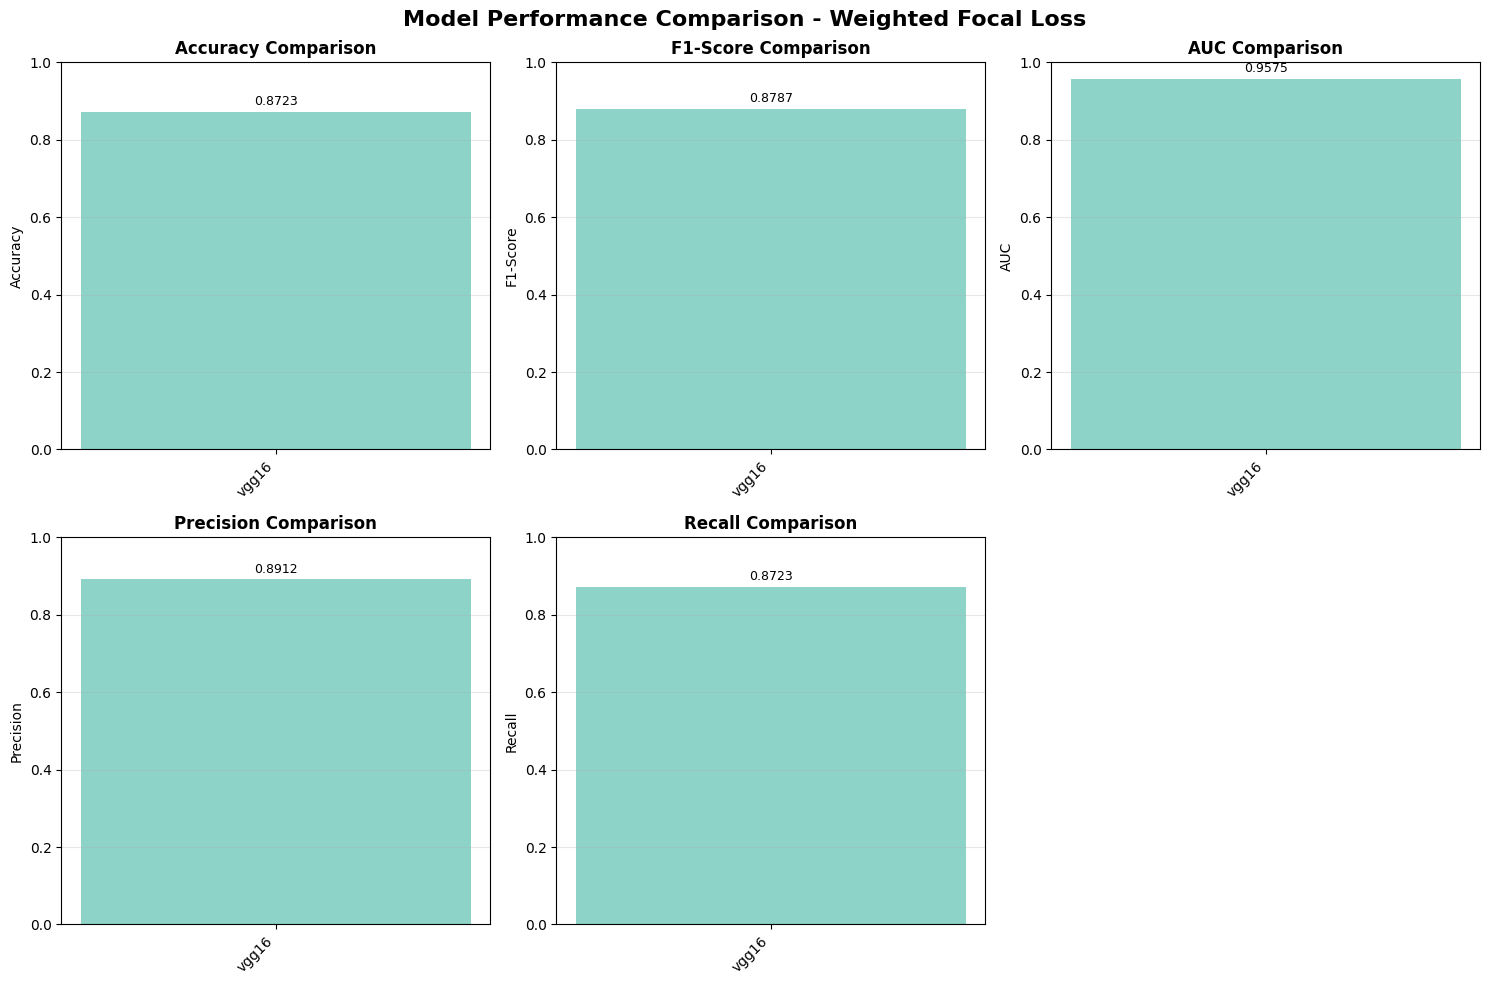

In [11]:
def train_model(model_name):
    """Hàm train model với Weighted Focal Loss và learning rate cố định"""
    print(f"\n{'='*60}")
    print(f"TRAINING {model_name.upper()}")
    print(f"{'='*60}")
    
    # Tạo model
    model = SimpleMultimodalModel(
        model_name=model_name,
        num_classes=NUM_CLASSES,
        metadata_dim=len(metadata_features),
        embedding_dim=TRAIN_CONFIG['metadata_embedding_dim'],
        dropout=TRAIN_CONFIG['dropout_rate']
    ).to(DEVICE)
    
    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    # Tính class weights với numerical stability
    labels = train_df['label'].values
    class_counts = np.bincount(labels)
    total = len(labels)
    
    # Tính weights với eps để tránh division by zero
    class_weights = total / (len(class_counts) * (class_counts + 1e-8))
    class_weights = class_weights / class_weights.sum() * len(class_counts)  # Normalize
    
    # Kiểm tra class weights
    class_weights_np = class_weights.copy()
    if np.isnan(class_weights_np).any() or np.isinf(class_weights_np).any():
        print("⚠️ Warning: Invalid class weights detected, using uniform weights")
        class_weights = np.ones(len(class_counts))
    
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
    
    print(f"\nClass weights (inverse frequency): {class_weights.cpu().numpy()}")
    print(f"Loss Function: Weighted Focal Loss (kết hợp Class-weighted Loss + Focal Loss)")
    print(f"Learning Rate: {TRAIN_CONFIG['learning_rate']} (cố định, không dùng scheduler)")
    
    # Tạo trainer
    trainer = ModelTrainer(
        model=model,
        model_name=model_name,
        device=DEVICE,
        class_weights=class_weights
    )
    
    # Training loop
    start_time = time.time()
    
    for epoch in range(TRAIN_CONFIG['num_epochs']):
        print(f"\nEpoch {epoch+1}/{TRAIN_CONFIG['num_epochs']}")
        
        # Training
        train_loss, train_acc, train_f1 = trainer.train_epoch(train_loader)
        
        # Validation
        val_loss, val_acc, val_f1 = trainer.validate(val_loader)
        
        # Update history
        trainer.history['train_loss'].append(train_loss)
        trainer.history['val_loss'].append(val_loss)
        trainer.history['train_acc'].append(train_acc)
        trainer.history['val_acc'].append(val_acc)
        trainer.history['train_f1'].append(train_f1)
        trainer.history['val_f1'].append(val_f1)
        trainer.history['lr'].append(TRAIN_CONFIG['learning_rate'])
        
        print(f"  Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"  Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
        print(f"  LR: {TRAIN_CONFIG['learning_rate']:.2e} (fixed)")
        
        # Save checkpoint
        is_best = val_acc > trainer.best_val_acc
        if is_best:
            trainer.best_val_acc = val_acc
            trainer.early_stop_counter = 0
            checkpoint_path = trainer.save_checkpoint(epoch+1, val_acc, is_best=True)
            print(f"  🏆 New best model! Saved to: {checkpoint_path}")
        else:
            trainer.early_stop_counter += 1
            checkpoint_path = trainer.save_checkpoint(epoch+1, val_acc, is_best=False)
            print(f"  Checkpoint saved: {checkpoint_path}")
        
        # Cleanup old checkpoints
        trainer.cleanup_old_checkpoints(keep_last=2)
        
        # Early stopping
        if trainer.early_stop_counter >= TRAIN_CONFIG['early_stopping_patience']:
            print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
            break
    
    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time/60:.2f} minutes")
    
    # Skip plot during training to save time (uncomment to view)
    # trainer.plot_training_history()
    
    # Evaluate on test set
    print(f"\nEvaluating {model_name} on test set...")
    test_metrics = trainer.evaluate_test(test_loader)
    
    # Print detailed metrics
    trainer.print_detailed_metrics(test_metrics)
    
    return trainer, test_metrics

# Train các model
results = {}
for model_name in MODEL_LIST:
    try:
        trainer, metrics = train_model(model_name)
        results[model_name] = {
            'trainer': trainer,
            'metrics': metrics
        }
    except Exception as e:
        print(f"Error training {model_name}: {e}")
        import traceback
        traceback.print_exc()
        continue

# Model comparison
if results:
    print(f"\n{'='*60}")
    print("MODEL COMPARISON")
    print(f"{'='*60}")
    
    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Accuracy': [results[m]['metrics']['accuracy'] for m in results],
        'F1-Score': [results[m]['metrics']['f1'] for m in results],
        'AUC': [results[m]['metrics']['auc'] for m in results],
        'Precision': [results[m]['metrics']['precision'] for m in results],
        'Recall': [results[m]['metrics']['recall'] for m in results]
    })
    
    print(comparison_df.to_string(index=False))
    
    # Plot comparison
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    metrics_to_plot = ['Accuracy', 'F1-Score', 'AUC', 'Precision', 'Recall']
    colors = plt.cm.Set3(np.linspace(0, 1, len(results)))
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 3, idx % 3]
        models = comparison_df['Model'].values
        values = comparison_df[metric].values
        
        bars = ax.bar(models, values, color=colors[:len(models)])
        ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        ax.set_ylabel(metric, fontsize=10)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add values on bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{value:.4f}', ha='center', va='bottom', fontsize=9)
    
    # Hide extra subplot
    axes[1, 2].axis('off')
    
    plt.suptitle('Model Performance Comparison - Weighted Focal Loss', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/model_comparison.png', dpi=100, bbox_inches='tight')  # Lower DPI for speed
    plt.show()


In [12]:
def create_final_report(results):
    """Tạo báo cáo tổng kết"""
    report = {
        'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        'dataset_info': {
            'total_samples': len(df),
            'train_samples': len(train_df),
            'val_samples': len(val_df),
            'test_samples': len(test_df),
            'class_distribution': {
                'benign': int(df['label'].value_counts()[0]),
                'malignant': int(df['label'].value_counts()[1]),
                'unknown': int(df['label'].value_counts()[2])
            }
        },
        'training_config': TRAIN_CONFIG,
        'model_results': {}
    }
    
    for model_name, result in results.items():
        report['model_results'][model_name] = {
            'accuracy': float(result['metrics']['accuracy']),
            'f1_score': float(result['metrics']['f1']),
            'auc': float(result['metrics']['auc']),
            'precision': float(result['metrics']['precision']),
            'recall': float(result['metrics']['recall'])
        }
    
    # Lưu report
    import json
    with open('/kaggle/working/final_report.json', 'w') as f:
        json.dump(report, f, indent=4)
    
    # In summary
    print(f"\n{'='*60}")
    print("FINAL SUMMARY REPORT")
    print(f"{'='*60}")
    
    print(f"\nDataset Information:")
    print(f"  Total samples: {report['dataset_info']['total_samples']}")
    print(f"  Train/Val/Test split: {len(train_df)}/{len(val_df)}/{len(test_df)}")
    print(f"  Class distribution:")
    print(f"    Benign: {report['dataset_info']['class_distribution']['benign']}")
    print(f"    Malignant: {report['dataset_info']['class_distribution']['malignant']}")
    print(f"    Unknown: {report['dataset_info']['class_distribution']['unknown']}")
    
    print(f"\nBest Model:")
    best_model = max(results.items(), key=lambda x: x[1]['metrics']['f1'])
    print(f"  {best_model[0]} with F1-Score: {best_model[1]['metrics']['f1']:.4f}")
    
    return report

# Tạo báo cáo
if results:
    final_report = create_final_report(results)
    print(f"\nReport saved to: /kaggle/working/final_report.json")


NameError: name 'datetime' is not defined